In [40]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
import time
import os
import cv2
import numpy as np
from modules_segmentation import *

In [41]:
processed_mask = cv2.imread(
    "/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/02_03_handcrafted_mask_fat.jpg", 
    cv2.IMREAD_GRAYSCALE
)
gridcorners = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/gridcorners.npy")
mask_h_line = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/mask_h_line.npy")

In [104]:
def get_h_mid_revised(image, mask_h):
    """
    Find the longest horizontal line in an image
    """

    def horizontal_mid_y(line):
        _, y1, _, y2 = line
        return (y1 + y2) / 2

    def line_length(line):
        x1, y1, x2, y2 = line
        return np.hypot(x2-x1, y2-y1)
    
    # invert so lines become white
    bw = cv2.bitwise_not(image)

    # detect lines
    lines = cv2.HoughLinesP(bw, 1, np.pi/180,
                            threshold=100,
                            minLineLength=1000,
                            maxLineGap=100)

    # filter for horizontal lines
    h_lines = []
    for l in lines:
        x1, y1, x2, y2 = l[0]
        angle = np.degrees(np.arctan2(y2-y1, x2-x1))
        if abs(angle) < 10:  # near horizontal
            h_lines.append((x1, y1, x2, y2))

    # restrict to central band to exclude borders of YST
    H = image.shape[0]
    upper_bound = H * 0.25
    lower_bound = H * 0.75
    h_lines_mid = [l for l in h_lines if upper_bound <= horizontal_mid_y(l) <= lower_bound]

    image_h = max(h_lines_mid, key = line_length)
    dy = get_midpoint(image_h)- get_midpoint(mask_h)

    if dy > 500:
        upper_bound = H * 0.25
        lower_bound = H * 0.5
        h_lines_mid = [l for l in h_lines if upper_bound <= horizontal_mid_y(l) <= lower_bound]

    if dy < 500:
        upper_bound = H * 0.5
        lower_bound = H * 0.75
        h_lines_mid = [l for l in h_lines if upper_bound <= horizontal_mid_y(l) <= lower_bound]


    if not h_lines_mid:
        return None

    # pick longest
    longest = max(h_lines_mid, key=line_length)
    
    return longest


/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/02_images_rotated/LIRIBO_0199.jpg


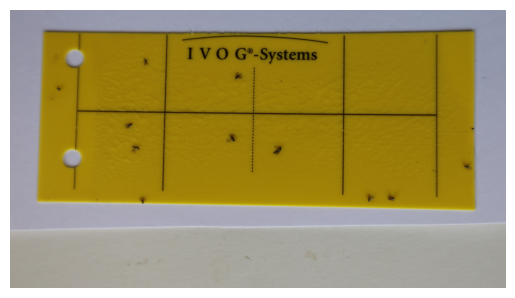

In [ ]:
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/02_images_rotated"
with open("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/logs/images_not_shifted_train_labeled.txt", "r") as f:
    unshifted = [line.strip() for line in f]
#image_file = "BRAIIM_0003.jpg"



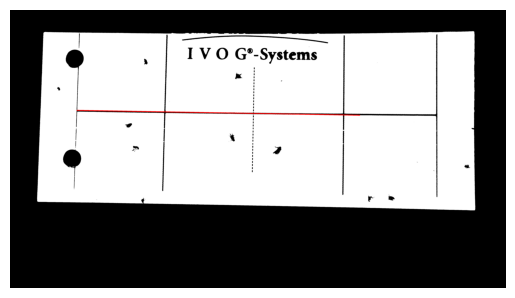

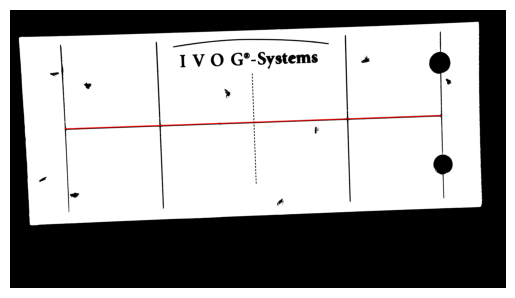

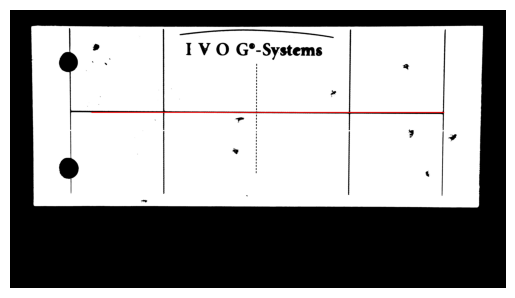

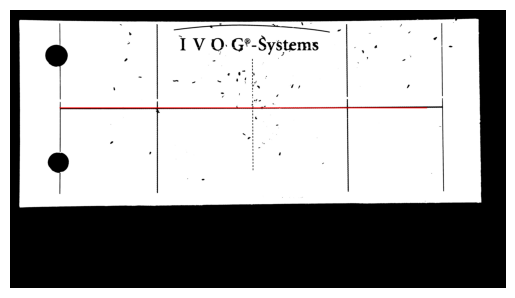

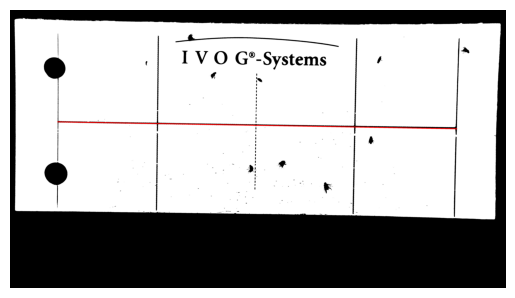

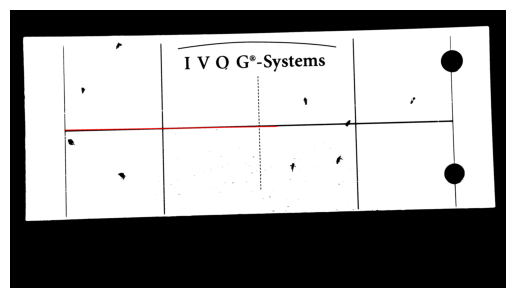

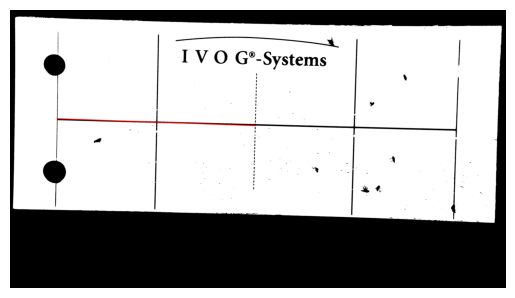

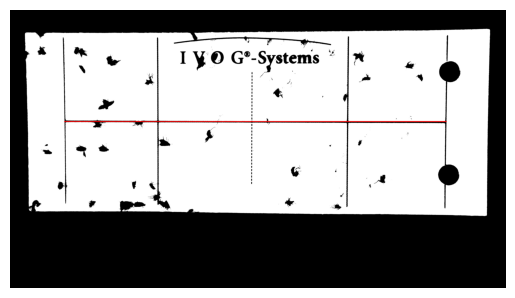

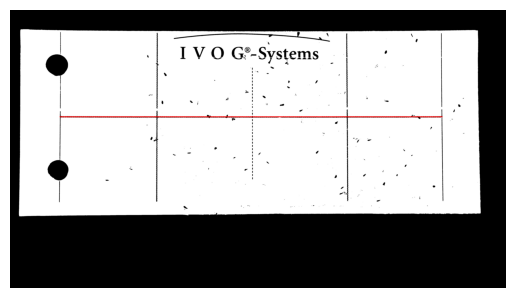

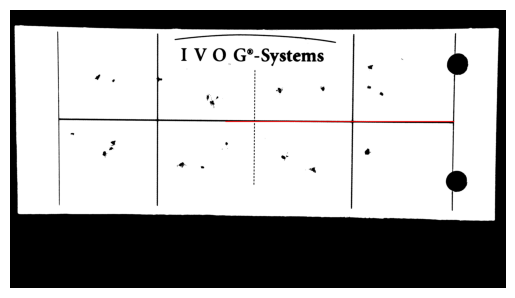

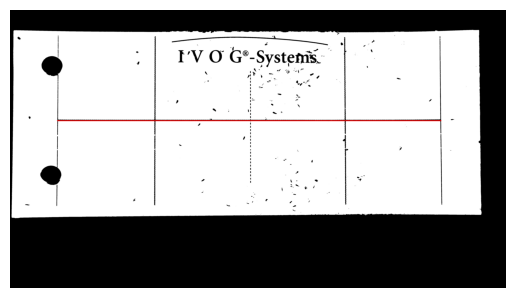

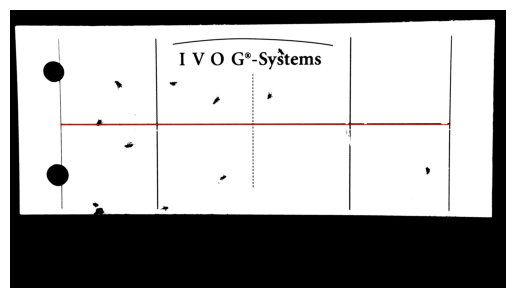

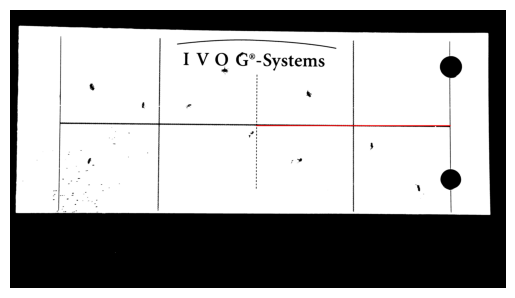

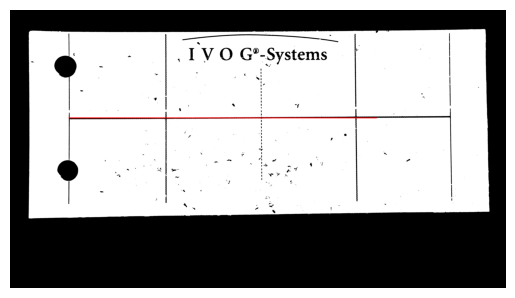

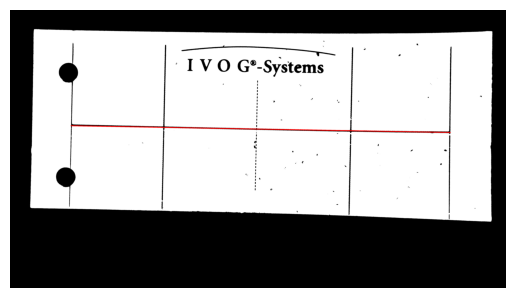

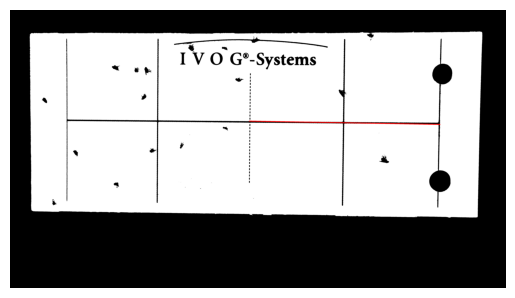

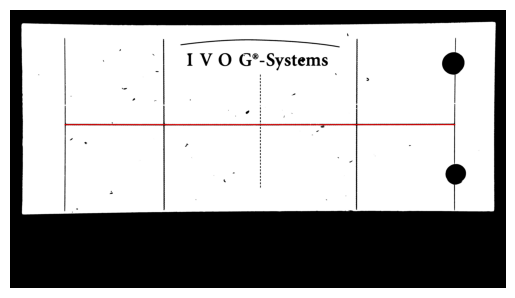

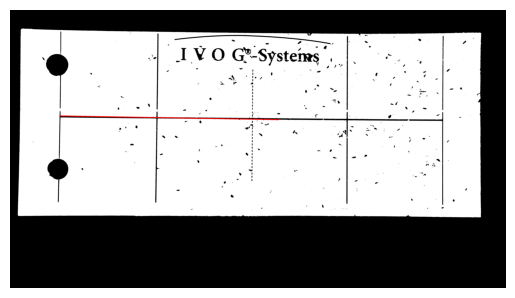

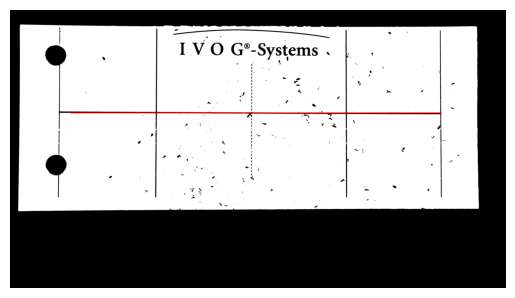

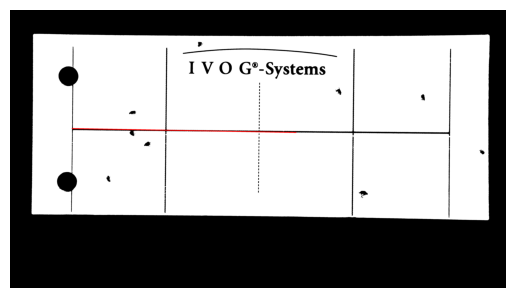

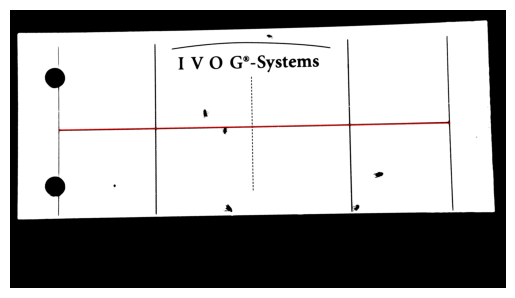

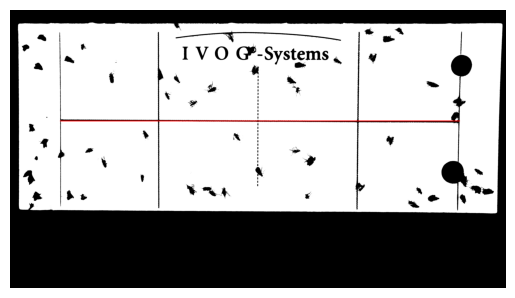

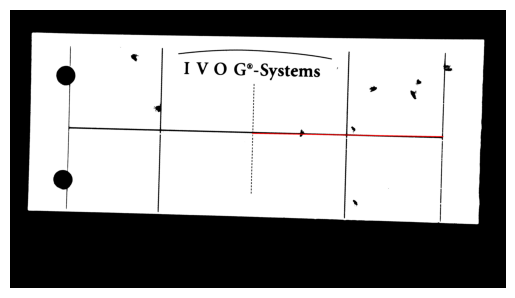

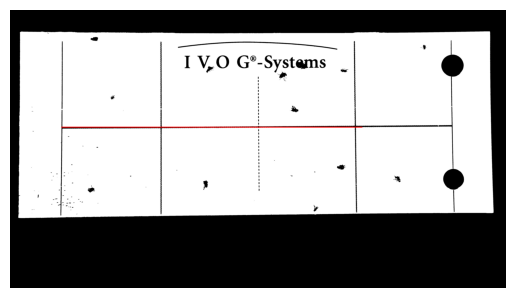

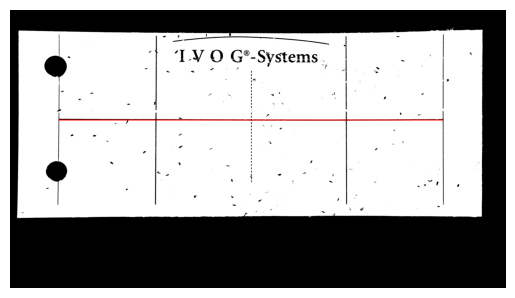

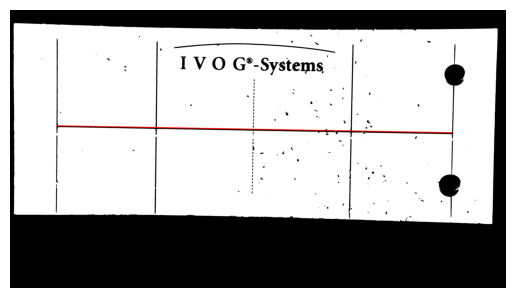

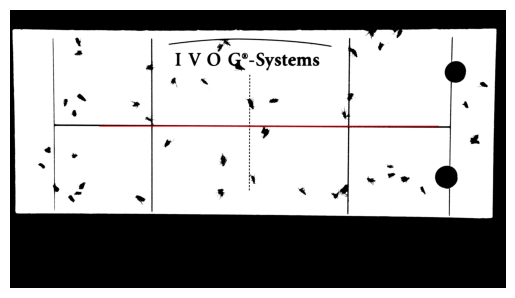

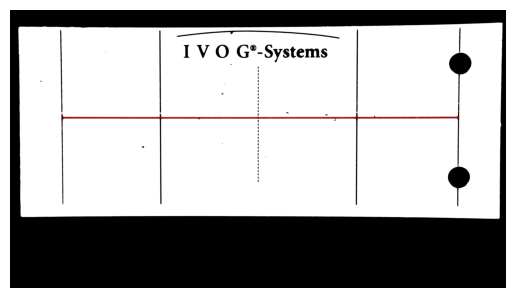

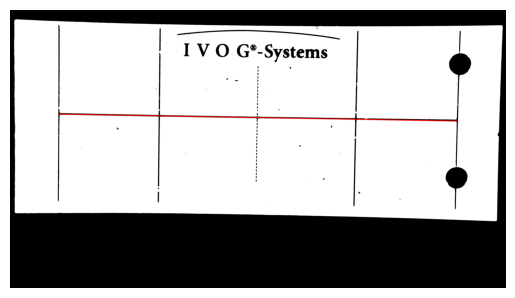

In [106]:
for i in range(len(unshifted)):
    image_file = os.path.join(image_folder, unshifted[i])
    #print(image_file)
    image = cv2.imread(os.path.join(image_folder, image_file))
     #find YST contour of image
    imageYST = find_contour(image)

    #save cropped image
    x, y, w, h = cv2.boundingRect(imageYST)
    cropped_image = image[y:y+h, x:x+w]

    #find corners if possible, if not skip the image
    imagecorners = find_corners(image, imageYST)

    #find transformation
    H, _ = cv2.findHomography(gridcorners, imagecorners, cv2.RANSAC)

    #first transformation: 
    mask = cv2.warpPerspective(processed_mask, H, (image.shape[1], image.shape[0]))

    #transform midline of mask as above
    h_line_pts = mask_h_line.reshape(-1,1,2)
    h_line_pts_warped = cv2.perspectiveTransform(h_line_pts, H)
    x1w, y1w, x2w, y2w = h_line_pts_warped.reshape(-1).astype(np.int32)
    mask_h = (x1w, y1w, x2w, y2w)
    image_h = get_h_mid_revised(create_binary_mask(image), mask_h)
    bw_color = cv2.cvtColor(create_binary_mask(image), cv2.COLOR_GRAY2BGR)
    x1, y1, x2, y2 = image_h
    cv2.line(bw_color, (x1, y1), (x2, y2), color=(0,0,255), thickness=10)
    show(bw_color)


In [ ]:
image_h = get_h_mid(create_binary_mask(image))
dy = get_midpoint(image_h)- get_midpoint(mask_h)
print (dy)
if abs(dy) > 500:
    print(f"Skipped vertical alignment, wrong horizontal line with offset {dy}")
    problems_shifts.append(image_file)

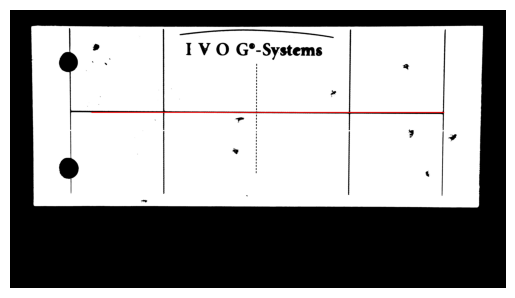

In [96]:
dy = get_midpoint(image_h)- get_midpoint(mask_h)
print (dy)

-22.5


In [114]:
import os
path = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/labels/val"
files = os.listdir(path)
files = [f for f in files if f.startswith("LIRIBO")]


In [115]:
len(files)

106

In [116]:
sum = 0
for f in files:
    with open(os.path.join(path, f), "r") as d:
        lines = d.readlines()
        sum += len(lines)
print(sum)

1054
